## DNN Assignment 1 - IMDB Movie Reviews Sentiment Classification
Group: 201

### Group Members:

1. RAMESH P.: 2024AB05263
2. JAGADI SHRUTI CHANABASAPPA: 2024AA05181
3. TANAY KASHYAP: 2024AA05991
4. SHIKHAR NIGAM: 2024AA05691

## Dataset 4: IMDB Movie reviews sentiment classification

### 1. Import Libraries

In [29]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from collections import Counter

from keras.datasets import imdb
import textwrap


In [30]:
# Set Random seeds
tf.random.set_seed(42)
np.random.seed(42)

### 2. IMDB Data Loading & Analysis
Total Corpus of words = 88000 <br>
Total Training Reviews = 25000 <br>
Total Test Reviews = 25000 <br>

Dataset Columns:
1. Movie Reviews -> Sequence of integers representing words
2. Sentiment Labels -> 0:Negative, 1:Positive

In [31]:
# Collect Training & Test sets from IMDB dataset module
# Though all unique words in the collection is around 88000, considering only 10000
# as one-hot encoding will create a vector in the dimension of 10000
most_frequent_words_to_consider = 10000 # all the words in the corpus
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=most_frequent_words_to_consider)

In [32]:
# Verify the size of training set & test set
total_training_reviews = {x_train.shape[0]}
total_test_reviews = {x_test.shape[0]}
print(f"Training Reviews Available: Reviews={x_train.shape[0]}, Labels={y_train.shape[0]}")
print(f"Test Reviews Available: Reviews={x_test.shape[0]}, Labels={y_test.shape[0]}")

Training Reviews Available: Reviews=25000, Labels=25000
Test Reviews Available: Reviews=25000, Labels=25000


### 3. Decide the dimension of ONE-HOT encoding for input data

Least frequent word from 10000 corpus is: 9990 with frequency 31



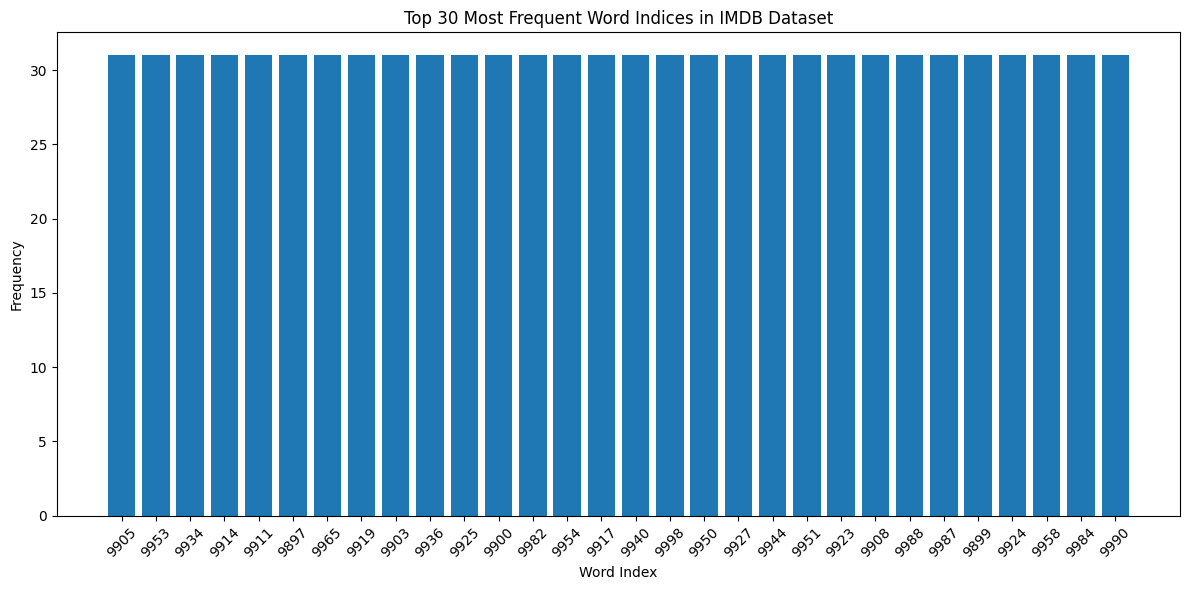

In [33]:
all_words = [word for review in x_train for word in review]

word_counts = Counter(all_words)

# Get the top N least common words
top_n = 30
least_common = word_counts.most_common()[:-top_n-1:-1]
words, freqs = zip(*least_common)

print(f"Least frequent word from {most_frequent_words_to_consider} corpus is: {least_common[-1][0]} with frequency {least_common[-1][1]}")
print()

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(top_n), freqs, tick_label=words)
plt.title(f"Top {top_n} Most Frequent Word Indices in IMDB Dataset")
plt.xlabel("Word Index")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Least frequent word from 10000 corpus is: 9990 with frequency 31 and continuing with 10000 word corpus

### 4. View the Reviews & Labels
Note: The IMDB dataset is already ordered the words in each review according to the vector semantics generated which assigns a integer value to each unique word

In [34]:
# Method to convert word encodings to words
def decode_review(text):
  word_index = imdb.get_word_index()
  reverse_word_index = {value: key for key, value in word_index.items()}
  decoded_review = ",".join([reverse_word_index.get(i, "?") for i in x_train[0]])
  return decoded_review

def decode_label(label):
  return "Positive" if label == 1 else "Negative"

In [35]:
# View the dataset
def view_imdb_dataset(records_to_view=5):
  print("="*150)
  print(f"{' '*40} Review - Sentiment ")
  print("="*150)
  for i in range(records_to_view):
    print(textwrap.fill(f"{','.join([str(x) for x in x_train[i]])}|{y_train[i]}", 150))
    print("-"*150)
    print(textwrap.fill(f"{decode_review(x_train[i])}|{decode_label(y_train[i])}", 150))
    print("-"*150)

reviews_to_view = 3
view_imdb_dataset(reviews_to_view)

                                         Review - Sentiment 
1,14,22,16,43,530,973,1622,1385,65,458,4468,66,3941,4,173,36,256,5,25,100,43,838,112,50,670,2,9,35,480,284,5,150,4,172,112,167,2,336,385,39,4,172,4536
,1111,17,546,38,13,447,4,192,50,16,6,147,2025,19,14,22,4,1920,4613,469,4,22,71,87,12,16,43,530,38,76,15,13,1247,4,22,17,515,17,12,16,626,18,2,5,62,386
,12,8,316,8,106,5,4,2223,5244,16,480,66,3785,33,4,130,12,16,38,619,5,25,124,51,36,135,48,25,1415,33,6,22,12,215,28,77,52,5,14,407,16,82,2,8,4,107,117,
5952,15,256,4,2,7,3766,5,723,36,71,43,530,476,26,400,317,46,7,4,2,1029,13,104,88,4,381,15,297,98,32,2071,56,26,141,6,194,7486,18,4,226,22,21,134,476,2
6,480,5,144,30,5535,18,51,36,28,224,92,25,104,4,226,65,16,38,1334,88,12,16,283,5,16,4472,113,103,32,15,16,5345,19,178,32|1
------------------------------------------------------------------------------------------------------------------------------------------------------
the,as,you,with,out,themselves,powerful,lets,loves,their,beco

### 4.1 Additional Check to see if all reviews are of same length

In [36]:
# Check if total words present in each of the reviews
def check_if_all_reviews_have_same_number_of_words(number_of_reviews_to_check=10):
  print("Review No. \t| Total Words")
  for i in range(number_of_reviews_to_check):
    print(f"{i+1} \t\t| {len(x_train[i])}")

print("No of words in each reviews:")
check_if_all_reviews_have_same_number_of_words()

print()
print("Other Summary:")
average_length = sum(len(review) for review in x_train) / len(x_train)
min_len = min(len(review) for review in x_train)
max_len = max(len(review) for review in x_train)

print(f"Average Length: {average_length}")
print(f"Min Length: {min_len}")
print(f"Max Length: {max_len}")


No of words in each reviews:
Review No. 	| Total Words
1 		| 218
2 		| 189
3 		| 141
4 		| 550
5 		| 147
6 		| 43
7 		| 123
8 		| 562
9 		| 233
10 		| 130

Other Summary:
Average Length: 238.71364
Min Length: 11
Max Length: 2494


### 5. ONE-HOT encode Training & Test Data

In [37]:
# Vectorize input data
corpus_size = most_frequent_words_to_consider
def vectorize_input(x, vector_size = corpus_size):
  vectorized_input = np.zeros((len(x), vector_size))
  for i, review in enumerate(x):
    vectorized_input[i, review] = 1.0 # float to allow precision points
  return vectorized_input


In [38]:
# vectorize input data and class labels
x_train_vectorized = vectorize_input(x_train)
x_test_vectorized = vectorize_input(x_test)

# convert prediction labels into arrays
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

In [39]:
# view the dimension of training & test set after input encoding & vectorisation
print(f"Training data shape: {x_train_vectorized.shape}")
print(f"Test data shape: {x_test_vectorized.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (25000, 10000)
Test data shape: (25000, 10000)
Training labels shape: (25000,)
Test labels shape: (25000,)


### 5A. Checking if contribution of positives & negatives same in the dataset

In [40]:
print("Training Set:")
y_array = np.array(y_train)

num_positives = np.sum(y_array == 1)
num_negatives = np.sum(y_array == 0)

print(f"num_positives: {num_positives}")
print(f"num_negatives: {num_negatives}")

Training Set:
num_positives: 12500
num_negatives: 12500


### 6. Create Training & Validation Split from Training data

In [41]:
# Create 80-20 validation split from training data - Since we have very large collection of data 20% = 5000 reviews

from sklearn.model_selection import train_test_split

x_training_split, x_validation_split, y_training_split, y_validation_split = train_test_split(
    x_train_vectorized,
    y_train,
    test_size=0.2,
    stratify=y_train  # ensures class distribution is preserved
)

### 6A. Checking if positive & negative class has same contribution

In [42]:
print("Training Set:")
y_array = np.array(y_training_split)

num_positives = np.sum(y_array == 1)
num_negatives = np.sum(y_array == 0)

print(f"num_positives: {num_positives}")
print(f"num_negatives: {num_negatives}")

print("Validation Set:")
y_array = np.array(y_validation_split)

num_positives = np.sum(y_array == 1)
num_negatives = np.sum(y_array == 0)

print(f"num_positives: {num_positives}")
print(f"num_negatives: {num_negatives}")

Training Set:
num_positives: 10000
num_negatives: 10000
Validation Set:
num_positives: 2500
num_negatives: 2500


### 7. Build DNN Model for Binary Classification
Points To Note:

1. Input Data Matrix = 25000 rows x 10000 columns (Each row is equalent to a review, each column is whether word at that index in word-semantic vector is present in the review or not)
2. Possible Depths: <br>
  More depth in DNN means capturing more complex patterns in the data. Below optimal depth may make the model underfit the data and above optimal depth will lead to overfitting. <br>
  We will start with <b> Depth=3 </b> as most DNN problems captured with depth=3
3. Possible widths: <br>
  Width of DNN helps to capture the input features in the data. Optimal Width needs to chosent to ensure we sufficiently use the input features <br>
  We will use the Tappered design, since it will help to compress and redefine learned parameters gradually. we will choose <b> 512 -> 256 -> 128 depths </b>
4. Output Layer - 1 (since it is binary classfication 0/1)
5. Activation Functions:<br>
  • For Output: Sigmoid (Since Binary Classification) <br>
  • For Hidden Layers: ReLU (suitable for text, image & general Deep learning tasks)<br>
6. Measures to prevent overfitting <br>
  • <b> Not considering all the data for training </b>: <br>
   1. Only 80% available training data is considered for training.
   2. Though 88000 unique words are available in the IMDB review dataset only most frequent 10000 words are considered for training, so it ensures generalization of the model. <br>

  • <b>Dropout mechanism</b>: <br>
  In DNN, more width captures more features. So it may be inherent in the data that some feature may dominate the other features. This could overfit the model generated. So we will randomly drop certain % of input features(neurons) at each level to ensure that the model utilizes all the input features and stays generalised. We are choosing <b> dropout = 0.5 % </b>

  • <b>Early Stop Mechanism</b> - we will enable the model to stop when it finds the validation loss starts to increase




In [43]:
from keras import Input
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

# Generate DNN Model
input_layer = {"name": "Input Layer"}
hidden_layer_1 = {"no_of_neurons": 2048, "activation": "relu", "name": "Hidden_Layer_1", "dropout_ratio": 0.5}
hidden_layer_2 = {"no_of_neurons": 1024, "activation": "relu", "name": "Hidden_Layer_2", "dropout_ratio": 0.5}
hidden_layer_3 = {"no_of_neurons": 512, "activation": "relu", "name": "Hidden_Layer_3", "dropout_ratio": 0.5}
hidden_layer_4 = {"no_of_neurons": 256, "activation": "relu", "name": "Hidden_Layer_4", "dropout_ratio": 0.5}
output_layer = {"no_of_neurons": 1, "activation": "sigmoid", "name": "Output_Layer"}

# input_shape = (most_frequent_words_to_consider,)

IMDB_DNN_model = Sequential([
  # Add input Layer
  Input(shape=(most_frequent_words_to_consider,), name=input_layer["name"]),

  # Add Hidden layer 1
  Dense(hidden_layer_1["no_of_neurons"], activation=hidden_layer_1["activation"], name=hidden_layer_1["name"]),
  Dropout(hidden_layer_1["dropout_ratio"], name="Dropout_H1"),

  # Add Hidden layer 2
  Dense(hidden_layer_2["no_of_neurons"], activation=hidden_layer_2["activation"], name=hidden_layer_2["name"]),
  Dropout(hidden_layer_2["dropout_ratio"], name='Dropout_H2'),

  # Add Hidden layer 3
  Dense(hidden_layer_3["no_of_neurons"], activation=hidden_layer_3["activation"], name=hidden_layer_3["name"]),
  Dropout(hidden_layer_3["dropout_ratio"], name='Dropout_H3'),

  # Add Hidden layer 4
  Dense(hidden_layer_4["no_of_neurons"], activation=hidden_layer_4["activation"], name=hidden_layer_4["name"]),
  Dropout(hidden_layer_4["dropout_ratio"], name='Dropout_H4'),

  # Output layer - binary classification (sigmoid activation)
  Dense(output_layer["no_of_neurons"], activation=output_layer["activation"], name=output_layer["name"])
])

### 8. View the Model Generated

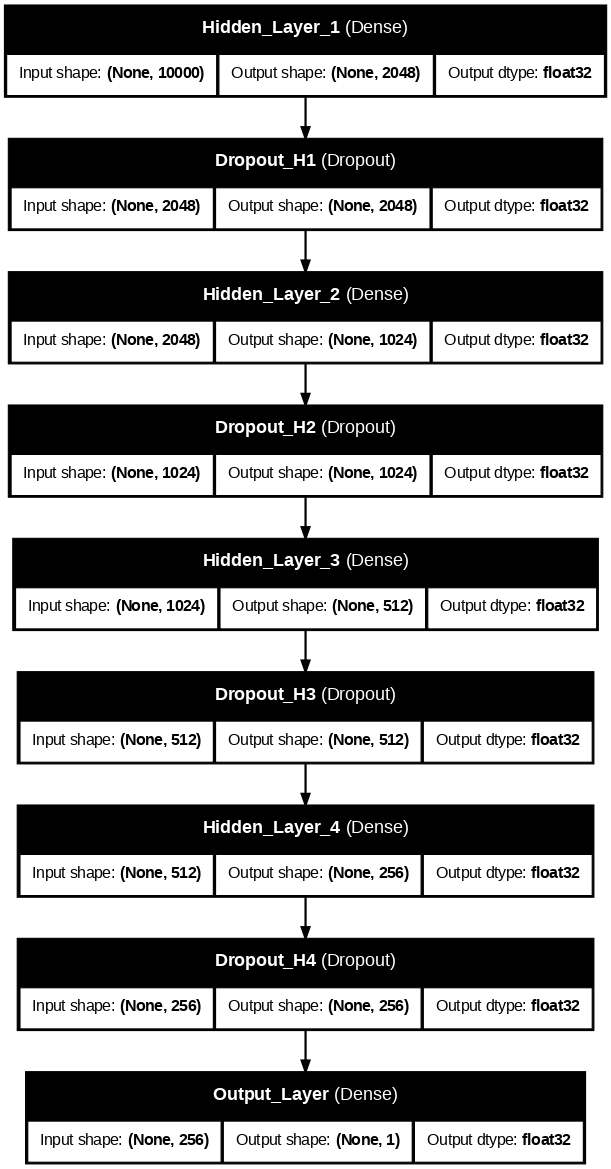

In [44]:
# keras.utils.plot_model(IMDB_DNN_model, show_shapes=True, show_layer_names=True, rankdir='TB')
keras.utils.plot_model(
    IMDB_DNN_model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=80
)

### 9. Compile the model with Training Data
1. Cost Function to Choose: <b> Binary Cross Entrophy Log Loss </b> (since sentiment analysis is a binary classification task)
2. Optimizer to choose: <br>
  • <b>Adam</b> - since it uses <u> momentum with adaptive learning rates</u> and <u> converges faster </u>
3. Metrics to monitor: <b>Accuracy</b><br>
Since we need to predict both posive & negative reviews correctly, Accuracy is the best measure to check

In [45]:
# Compile the model
optimizer_chosen = "adam"
loss_algorithm_chosen = "binary_crossentropy"
metrics_to_monitor = ['accuracy']
IMDB_DNN_model.compile(
    optimizer=optimizer_chosen,
    loss=loss_algorithm_chosen,
    metrics=metrics_to_monitor
)

### 9A. Train the model with validation dataset
Thins to note:
1. Epochs - number of iterations to run before finalizing the model parameter
2. Batch_size - no of reviews to use for each iteration
3. Early Stopping - to avoid unnecessary iterations & for taking best scores

In [46]:
from keras.callbacks import EarlyStopping

# Train & validate the model
EPOCHS = 10
BATCH_SIZE = 64

# Add Early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=1,
    restore_best_weights=True,    verbose=1
)

training_summary = IMDB_DNN_model.fit(
    x_training_split,
    y_training_split,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_validation_split, y_validation_split),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 151s 476ms/step - accuracy: 0.7544 - loss: 0.4760 - val_accuracy: 0.8848 - val_loss: 0.2830
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 478ms/step - accuracy: 0.9209 - loss: 0.2027 - val_accuracy: 0.8796 - val_loss: 0.3278
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


### 9B. Observation from the training
Based on accuracy metrics for various configuration of the DNN model, The validation accuracy is has not improved beyond 88% mark.

And hence moving further with this configuraiton <br>

hidden_layer_1 = {"no_of_neurons": 2048, "activation": "relu", "name": "Hidden_Layer_1", "dropout_ratio": 0.5} <br>
hidden_layer_2 = {"no_of_neurons": 1024, "activation": "relu", "name": "Hidden_Layer_2", "dropout_ratio": 0.5} <br>
hidden_layer_3 = {"no_of_neurons": 512, "activation": "relu", "name": "Hidden_Layer_3", "dropout_ratio": 0.5} <br>
hidden_layer_4 = {"no_of_neurons": 256, "activation": "relu", "name": "Hidden_Layer_4", "dropout_ratio": 0.5} <br>

### 9C. View the training summary

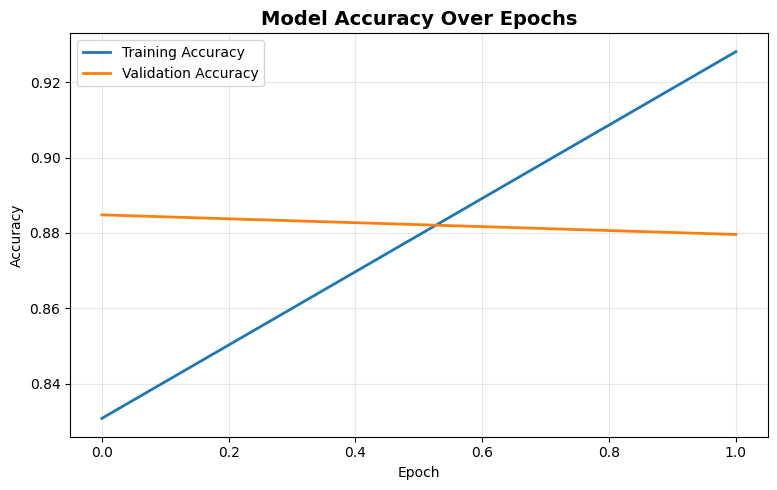

In [50]:

plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(training_summary.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(training_summary.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10. Evalution using Test Dataset

In [48]:
test_loss, test_accuracy = IMDB_DNN_model.evaluate(x_test_vectorized, y_test, verbose=0)
print(f"Test Accuracy %: {round(test_accuracy,4) * 100}")

Test Accuracy %: 87.74


### 10A. Generating classification report

In [49]:
predictions = IMDB_DNN_model.predict(x_test_vectorized)
predicted_classes = (predictions > 0.5).astype(int).flatten()
print(classification_report(y_test, predicted_classes, target_names=['Negative', 'Positive']))

782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step
              precision    recall  f1-score   support

    Negative       0.85      0.92      0.88     12500
    Positive       0.91      0.84      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



### 11. Summary
1. The IMDB Dataset is a collection preprocessed movie reviews. It is word embedded and hence directly usable in the DNN model
2. The problem given is a Binary Classification problem of either Positive or Negative Review
3. Input vector dimension of 10000 (most occuring words) is chosen since the words below it have appeared only less than 30 times in 25000 reviews. And those not included words will have minimal impact in the training
4. 80-20 training validation split is taken since we have 25000 training instances and 20% = 5000 is sufficient for validation
5. Training & validation validation split ensured to have equal representation of positive and negative classess
6. On multiple iterations accuracy is measured to be around 88 %. It appears this is the optimal accuracy for the current word embedding. To improve accuracy further revised word embedding which includes relative position of words may be tried.
7. Classification report also shows equal distribution of accuracy for both positive and negative class, confirming the reliability of model built.